# <center> VAI Store - Modelo Preditivo </center>

---

Este notebook implementa o modelo preditivo final. Com base no dataset de features, que é agregado por SKU e focado no FATUR_TOTAL, o objetivo é construir um modelo "global" que aprenda os padrões de todos os produtos simultaneamente.

Esta abordagem (modelar R$ por SKU) permite-nos responder às perguntas de negócio do case (sobre o SKU 1813), ao mesmo tempo que resolve o problema de unidades de medida (R$ vs. KG/UN). Usamos um modelo LightGBM e validamos sua performance ("acurácia") usando uma Validação Cruzada Temporal para garantir a robustez ao longo de diferentes épocas do ano.

### 1. Imports e Carregamento de Dados

Visão Geral: Esta etapa importa as bibliotecas essenciais (pandas, lightgbm, sklearn.metrics) e carrega o dataset final (feature_engineered_dataset_SKU.parquet). O dataset é lido rapidamente do formato Parquet e o tipo de dado datetime é garantido para as operações de série temporal.

In [171]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.parquet')

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

### 2. Preparação de Features e Alvo

Visão Geral: O dataset é preparado. 
* O alvo (y) é definido como FATUR_TOTAL. 
* As features categóricas (como SKU, CATEGORIA, INTERACAO_...) são explicitamente convertidas para o dtype 'category', o que é uma otimização essencial para o LightGBM. 
* As colunas redundantes (como DATA_ATEND) e o alvo são removidos da lista final de features (X).

In [172]:
# 1) Alvo
TARGET = 'FATUR_TOTAL'

# 2) Lista FINAL de features (as que estamos usando no modelo)
desired_features = [
    'SKU', 'DIA_SEMANA',
    'bacalhau_tier',           # 0/1/2
    'bacalhau_evento_forca',   # Páscoa/Natal/Jan20 (composta)
    'bacalhau_pos_natal',      # decaimento pós-Natal (0–1)
    'FATUR_TOTAL_LAG_1_NORM',  'FATUR_TOTAL_LAG_7_NORM',
    'FOURIER_MES_SIN', 'FOURIER_MES_COS',
    'loja_fechada'
]

# 3) Categóricas usadas
categorical_features = ['SKU', 'DIA_SEMANA', 'bacalhau_tier']

# 4) Dtypes
# 4.1 Categóricas
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Aviso: Coluna categórica '{col}' não encontrada no DataFrame.")

# 4.2 Numéricas (float32)
num_float_cols = [
    'bacalhau_evento_forca',
    'FATUR_TOTAL_LAG_1_NORM',  'FATUR_TOTAL_LAG_7_NORM',
    'FOURIER_MES_SIN', 'FOURIER_MES_COS'
]
for col in num_float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')
    else:
        print(f"Aviso: Variável numérica '{col}' não encontrada no DataFrame.")

# 4.3 Inteiras
if 'loja_fechada' in df.columns:
    df['loja_fechada'] = pd.to_numeric(df['loja_fechada'], errors='coerce').fillna(1).astype('int8')
else:
    print("Aviso: Variável 'loja_fechada' não encontrada no DataFrame.")

# 5) Monta X (apenas o que existe)
features_missing = [c for c in desired_features if c not in df.columns]
if features_missing:
    print("Atenção: as seguintes features desejadas não estão no DataFrame:", features_missing)

features = [c for c in desired_features if c in df.columns]

# 6) Remoções padrão
features_to_drop = [TARGET, 'DATA_ATEND', 'NOME_PRODUTO']  # compatibilidade
features = [c for c in features if c not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")
df[features].info()


Total de features para o modelo: 10
Alvo: FATUR_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21594 entries, 0 to 21593
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   SKU                     21594 non-null  category
 1   DIA_SEMANA              21594 non-null  category
 2   bacalhau_tier           21594 non-null  category
 3   bacalhau_evento_forca   21594 non-null  float32 
 4   bacalhau_pos_natal      21594 non-null  float32 
 5   FATUR_TOTAL_LAG_1_NORM  21594 non-null  float32 
 6   FATUR_TOTAL_LAG_7_NORM  21594 non-null  float32 
 7   FOURIER_MES_SIN         21594 non-null  float32 
 8   FOURIER_MES_COS         21594 non-null  float32 
 9   loja_fechada            21594 non-null  int8    
dtypes: category(3), float32(6), int8(1)
memory usage: 593.4 KB


### 3. Divisão de Dados (Train/Validation Split)

Visão Geral: Para garantir que a performance do modelo é robusta ao longo do ano, esta etapa utiliza uma Validação Cruzada Manual. O modelo é treinado e testado em 3 períodos distintos, capturando diferentes sazonalidades: Abril, Agosto e Dezembro. O erro final será a média dos resultados nestes três folds, fornecendo uma métrica de acurácia mais imparcial.

In [173]:
# Define os períodos de validação (Abril, Agosto, Dezembro)
validation_periods = [
    ('2024-04-01', '2024-04-30'), 
    ('2024-08-01', '2024-08-31'), 
    ('2024-12-01', '2024-12-31')
]

print(f"Validação configurada com {len(validation_periods)} folds.")

Validação configurada com 3 folds.


### 4. Treinamento em Loop (Cross-Validation)

Visão Geral: Esta etapa executa o loop de treinamento. O modelo é treinado 3 vezes, usando os parâmetros definidos para o LightGBM. O objetivo (regression_l2) é configurado para penalizar erros grandes (RMSE), forçando o modelo a prestar atenção aos picos de faturamento que ocorrem no SKU 1813. O argumento categorical_feature é passado para o .fit(), garantindo que o modelo "veja" e utilize as nossas regras de negócio.

In [174]:
# Lista para armazenar os resultados
scores_rmse = []
scores_mae = []
all_fold_results = []

# Loop de Cross-Validation Manual
for i, (val_start, val_end) in enumerate(validation_periods):
    fold_name = f"Fold {i+1} (Val: {pd.to_datetime(val_start).strftime('%b/%Y')})"
    print(f"\n--- {fold_name} ---")
    
    # Define a data de corte do treino
    train_end = pd.to_datetime(val_start) - pd.DateOffset(days=1)
    
    # Separa os dados de treino e validação
    df_train = df[df['DATA_ATEND'] <= train_end]
    df_val = df[(df['DATA_ATEND'] >= val_start) & (df['DATA_ATEND'] <= val_end)]
    
    X_train = df_train[features]
    y_train = df_train[TARGET]
    X_val = df_val[features]
    y_val = df_val[TARGET]
    
    # Define os parâmetros do LGBM
    params = {
        'objective': 'regression_l2',
        'metric': 'rmse',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbose': -1, # <-- Silencia o output do LightGBM
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }

    # Inicializa o modelo
    model_cv = lgb.LGBMRegressor(**params)

    # Treina o modelo (o log_evaluation foi removido para evitar output não padronizado)
    model_cv.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50)
        ],
        categorical_feature=categorical_features
    )
    
    # --- Avaliação do Fold (Saída Padronizada) ---
    y_pred = model_cv.predict(X_val)
    y_pred[y_pred < 0] = 0
    
    rmse_fold = np.sqrt(mean_squared_error(y_val, y_pred))
    mae_fold = mean_absolute_error(y_val, y_pred)
    
    print("---------------------------------------")
    print(f"RESUMO DO {fold_name}:")
    print(f"   RMSE Final: R$ {rmse_fold:,.2f}")
    print(f"   MAE Final:  R$ {mae_fold:,.2f}")
    print("---------------------------------------")
    
    scores_rmse.append(rmse_fold)
    scores_mae.append(mae_fold)
    
    # --- Armazena os resultados detalhados ---
    df_val_fold_results = X_val.copy()
    df_val_fold_results[TARGET] = y_val
    df_val_fold_results['Previsto'] = y_pred
    df_val_fold_results['DATA_ATEND'] = df_val['DATA_ATEND']
    df_val_fold_results['Fold'] = fold_name
    all_fold_results.append(df_val_fold_results)

print("\nTreinamento em Cross-Validation concluído.")


--- Fold 1 (Val: Apr/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[48]	valid_0's rmse: 228.213
---------------------------------------
RESUMO DO Fold 1 (Val: Apr/2024):
   RMSE Final: R$ 228.21
   MAE Final:  R$ 111.68
---------------------------------------

--- Fold 2 (Val: Aug/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[73]	valid_0's rmse: 185.464
---------------------------------------
RESUMO DO Fold 2 (Val: Aug/2024):
   RMSE Final: R$ 185.40
   MAE Final:  R$ 103.60
---------------------------------------

--- Fold 3 (Val: Dec/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[81]	valid_0's rmse: 1068.26
---------------------------------------
RESUMO DO Fold 3 (Val: Dec/2024):
   RMSE Final: R$ 1,067.97
   MAE Final:  R$ 390.34
---------------------------------------

Treinamento em Cross-Validation co

### 5. Avaliação de Performance (Média dos Folds)

Visão Geral: Esta etapa calcula a performance média do modelo, fornecendo uma métrica de "acurácia" imparcial e robusta. O desvio padrão (std) indica o quão estável é a performance do modelo entre os diferentes períodos do ano (Páscoa, Mês Normal e Natal).

In [175]:
# Converte as listas de scores em arrays numpy para estatísticas
scores_rmse = np.array(scores_rmse)
scores_mae = np.array(scores_mae)

# Calcula a média e o desvio padrão
mean_rmse = scores_rmse.mean()
std_rmse = scores_rmse.std()

mean_mae = scores_mae.mean()
std_mae = scores_mae.std()

print("\n--- Métricas Médias de Performance (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")

print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")


--- Métricas Médias de Performance (Cross-Validation) ---
RMSE Médio: R$ 493.86 (± R$ 406.33)
MAE Médio:  R$ 201.87 (± R$ 133.31)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 201.87.


### 6. Análise de Importância das Features

Visão Geral: Para validar a nossa lógica de negócio, plotamos a "importância das features" do último modelo treinado (Fold 3). Esperamos ver as features de lag normalizadas e as features de INTERACAO_... no topo, confirmando que o modelo está a usar as regras de negócio criadas.

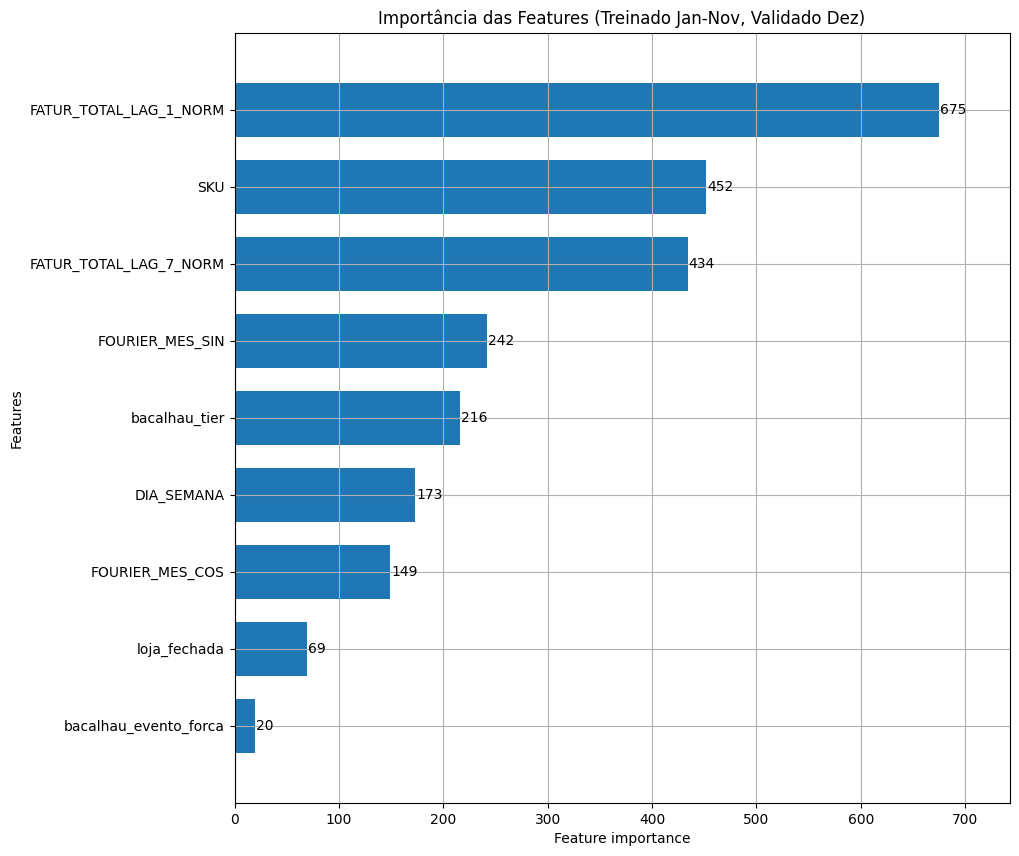

In [176]:
# Plotar a importância das features
# Usamos 'model_cv', que foi o nome do modelo dentro do loop
lgb.plot_importance(model_cv, figsize=(10, 10), max_num_features=25, height=0.7)
plt.title("Importância das Features (Treinado Jan-Nov, Validado Dez)")
plt.show()

### 7. Análise de Erros (Foco no SKU 1813)

Visão Geral: Esta etapa é crucial para responder diretamente à Pergunta 2 do case. Consolida os resultados de todos os 3 folds de validação, foca-se no SKU 1813 e calcula o erro médio e percentual deste produto específico em diferentes períodos do ano.


--- Análise SKU 1813 (Todos os períodos de Validação) ---
Faturamento Médio Real (SKU 1813): R$ 2,119.93
MAE Específico (SKU 1813):         R$ 947.49
Erro Percentual (SKU 1813):       44.69%


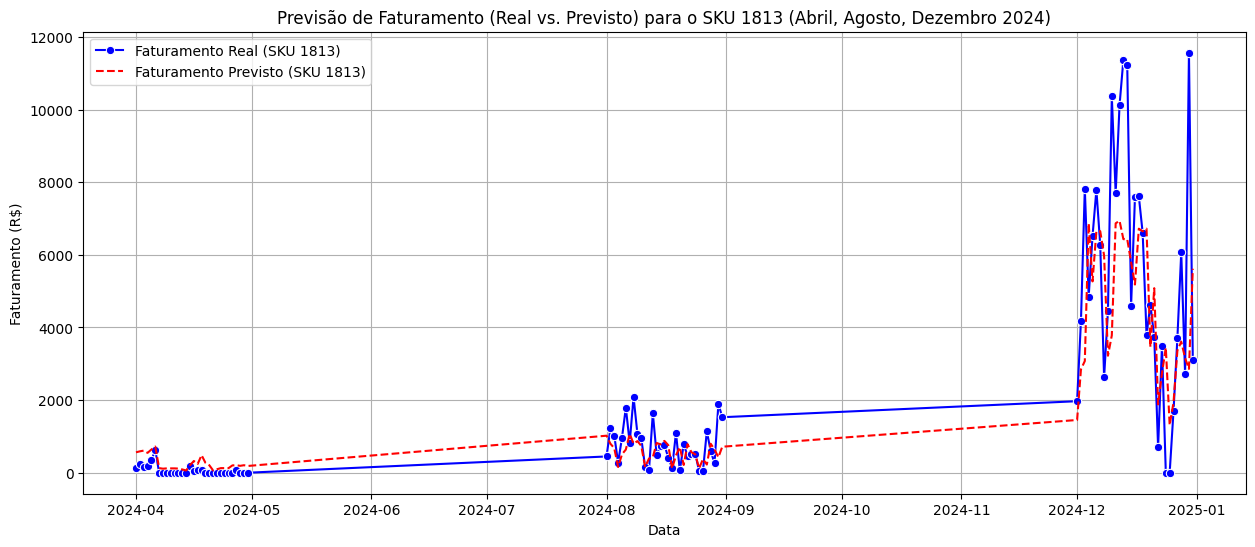

In [177]:
# Concatena os resultados de todos os folds em um único DataFrame
df_all_results = pd.concat(all_fold_results)

# Filtra para o SKU 1813
df_sku_1813 = df_all_results[df_all_results['SKU'] == 1813].copy()
df_sku_1813['DATA_ATEND'] = pd.to_datetime(df_sku_1813['DATA_ATEND'])

# Calcula o MAE específico
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()

print(f"\n--- Análise SKU 1813 (Todos os períodos de Validação) ---")
print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")


# Plotar a série temporal Real vs. Previsto para o SKU 1813
if not df_sku_1813.empty:
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y=TARGET, label='Faturamento Real (SKU 1813)', color='blue', marker='o')
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y='Previsto', label='Faturamento Previsto (SKU 1813)', color='red', linestyle='--')
    plt.title('Previsão de Faturamento (Real vs. Previsto) para o SKU 1813 (Abril, Agosto, Dezembro 2024)')
    plt.ylabel('Faturamento (R$)')
    plt.xlabel('Data')
    plt.legend()
    plt.grid(True)
    plt.show()

### 8. Impressão dos Resultados Finais (Consolidação)

Visão Geral: Esta etapa consolida os resultados do Cross-Validation e a análise de erros. A seção 1 imprime as métricas médias de RMSE e MAE (do loop da Etapa 5). A seção 2 imprime a tabela de features e, finalmente, a seção 3 imprime a análise detalhada do SKU 1813 (do dataframe consolidado da Etapa 7), fornecendo todas as informações necessárias para as conclusões do case.

In [178]:
# --- 1. MÉTRICAS GLOBAIS (Média de todos os Folds) ---
print("\n" + "="*70)
print("--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")
print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")
print("="*70)

# --- 2. IMPORTÂNCIA DAS FEATURES (Do último modelo) ---
print("\n--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo) ---")
try:
    # Wrapper sklearn
    df_importancia = pd.DataFrame({
        'feature': model_cv.feature_name_,
        'importance': model_cv.feature_importances_
    }).sort_values(by='importance', ascending=False)
except AttributeError:
    # Booster nativo (fallback)
    booster = model_cv.booster_
    df_importancia = pd.DataFrame({
        'feature': booster.feature_name(),
        'importance': booster.feature_importance(importance_type='gain')
    }).sort_values(by='importance', ascending=False)

print(df_importancia.to_string(index=False))
print("-" * 70)

# --- 3. ANÁLISE DE ERROS (FOCO SKU 1813) ---
print("\n--- 3. ANÁLISE ESPECÍFICA DO SKU 1813 (Todos os períodos de Validação) ---")
df_sku_1813 = df_all_results[df_all_results['SKU'].astype(str) == '1813'].copy()

# Segurança: evita crash se não houver linhas
if df_sku_1813.empty:
    print("Aviso: Não há registros do SKU 1813 nos períodos de validação.")
else:
    sku_1813_fatur_medio = df_sku_1813[TARGET].mean()
    sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])

    print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
    print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

    if sku_1813_fatur_medio > 0:
        print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
    else:
        print("SKU 1813 não teve faturamento no período de validação.")

    # --- Detalhe Diário (colunas opcionais, sem quebrar caso não existam) ---
    print("\n--- Detalhe Diário SKU 1813 (Real vs. Previsto) ---")
    optional_cols = [
        'FATUR_TOTAL_LAG_1_NORM',
        # aceita antigo nome ou as novas compactas:
        'intensidade_natal_bacalhau', 'bacalhau_evento_forca', 'bacalhau_pos_natal',
        'loja_fechada'
    ]
    base_cols = ['DATA_ATEND', TARGET, 'Previsto']
    present_cols = base_cols + [c for c in optional_cols if c in df_sku_1813.columns]

    df_sku_1813_debug = df_sku_1813[present_cols].copy()
    print(df_sku_1813_debug.to_string(index=False, float_format='%.2f'))
    print("-" * 70)



--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---
RMSE Médio: R$ 493.86 (± R$ 406.33)
MAE Médio:  R$ 201.87 (± R$ 133.31)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 201.87.

--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo) ---
               feature  importance
FATUR_TOTAL_LAG_1_NORM         675
                   SKU         452
FATUR_TOTAL_LAG_7_NORM         434
       FOURIER_MES_SIN         242
         bacalhau_tier         216
            DIA_SEMANA         173
       FOURIER_MES_COS         149
          loja_fechada          69
 bacalhau_evento_forca          20
    bacalhau_pos_natal           0
----------------------------------------------------------------------

--- 3. ANÁLISE ESPECÍFICA DO SKU 1813 (Todos os períodos de Validação) ---
Faturamento Médio Real (SKU 1813): R$ 2,119.93
MAE Específico (SKU 1813):         R$ 947.49
Erro Percentual (SKU 1813):       44.69%

--- Detalhe Diário SKU 1813 (Real vs. Previsto) ---
DATA_

# <Center> Previsão SKU 1813 <Center>

---

### 1. Objetivo e recorte temporal

Visão Geral: Treinar com todo 2024 (todos os SKUs) para um modelo generalista, e prever JAN/2025 apenas para o SKU 1813.

In [179]:
# Bloco 1 — Recorte temporal
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'], errors='coerce')

train_start = pd.Timestamp('2024-01-01')
train_end   = pd.Timestamp('2024-12-31')

df_train = df[(df['DATA_ATEND'] >= train_start) & (df['DATA_ATEND'] <= train_end)].copy()
print(f"Treino: {df_train['DATA_ATEND'].min().date()} → {df_train['DATA_ATEND'].max().date()} | Linhas: {len(df_train):,}")


Treino: 2024-01-01 → 2024-12-31 | Linhas: 21,594


### 2. Tipos e treino do modelo

Visão Geral: Converte categóricas para category e treina um LightGBM simples e estável.

In [180]:
# === Treino FINAL (2024) com exatamente as 10 features desejadas ===
import numpy as np
import pandas as pd
import lightgbm as lgb


# 0) Configurações básicas
TARGET = 'FATUR_TOTAL'
features_exact = [
    'SKU', 'DIA_SEMANA', 'bacalhau_tier',
    'bacalhau_evento_forca', 'bacalhau_pos_natal',
    'FATUR_TOTAL_LAG_1_NORM', 'FATUR_TOTAL_LAG_7_NORM',
    'FOURIER_MES_SIN', 'FOURIER_MES_COS',
    'loja_fechada'
]
categorical_features = ['SKU', 'DIA_SEMANA', 'bacalhau_tier']  # exatamente essas

# 1) Recorte do treino (todo 2024)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'], errors='coerce')
mask_2024 = (df['DATA_ATEND'] >= '2024-01-01') & (df['DATA_ATEND'] <= '2024-12-31')
df_train = df.loc[mask_2024].copy()

# 2) Checagem de presença das colunas
missing = [c for c in features_exact + [TARGET] if c not in df_train.columns]
if missing:
    raise ValueError(f"As seguintes colunas exigidas não estão em df_train: {missing}")

# 3) Dtypes — exatamente conforme especificado
# 3.1 Categóricas
for c in categorical_features:
    df_train[c] = df_train[c].astype('category')

# 3.2 Numéricas float32
float_cols = [
    'bacalhau_evento_forca', 'bacalhau_pos_natal',
    'FATUR_TOTAL_LAG_1_NORM', 'FATUR_TOTAL_LAG_7_NORM',
    'FOURIER_MES_SIN', 'FOURIER_MES_COS'
]
for c in float_cols:
    df_train[c] = pd.to_numeric(df_train[c], errors='coerce').astype('float32')

# 3.3 Int para loja_fechada
df_train['loja_fechada'] = (
    pd.to_numeric(df_train['loja_fechada'], errors='coerce')
    .fillna(1).astype('int8')
)

# 3.4 Alvo
df_train[TARGET] = pd.to_numeric(df_train[TARGET], errors='coerce').fillna(0).astype('float32')

# 4) Monta X/y com APENAS as 10 features
X_train = df_train[features_exact]
y_train = df_train[TARGET]

# 5) Hiperparâmetros — mesmos do seu CV
params_cv_like = dict(
    objective='regression_l2',
    metric='rmse',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    boosting_type='gbdt',
    n_jobs=-1,
    seed=42,
    verbose=-1
)

# 6) Treino final
model_full = lgb.LGBMRegressor(**params_cv_like)
model_full.fit(
    X_train, y_train,
    categorical_feature=[c for c in categorical_features if c in X_train.columns]
)

print(">> Colunas efetivamente usadas no treino:")
print(list(X_train.columns))

# 7) Importância das features (checagem rápida)
imp = pd.DataFrame({
    'feature': model_full.feature_name_,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=False)
print("\n--- Importância das Features ---")
print(imp.to_string(index=False))


>> Colunas efetivamente usadas no treino:
['SKU', 'DIA_SEMANA', 'bacalhau_tier', 'bacalhau_evento_forca', 'bacalhau_pos_natal', 'FATUR_TOTAL_LAG_1_NORM', 'FATUR_TOTAL_LAG_7_NORM', 'FOURIER_MES_SIN', 'FOURIER_MES_COS', 'loja_fechada']

--- Importância das Features ---
               feature  importance
FATUR_TOTAL_LAG_1_NORM        8185
FATUR_TOTAL_LAG_7_NORM        7993
 bacalhau_evento_forca        4037
                   SKU        2573
       FOURIER_MES_SIN        1954
       FOURIER_MES_COS        1672
         bacalhau_tier        1527
            DIA_SEMANA        1144
    bacalhau_pos_natal         812
          loja_fechada         103


### 3. Moldura de previsão (JAN/2025, SKU 1813)

Visão Geral: Cria a base de previsão diária com calendário, Fourier de mês e Feature A (intensidades + dias desde Natal). Herdamos metadados do SKU a partir do fim de 2024.

In [181]:
# ===== Bloco 3 — Moldura de previsão JAN/2025 (APENAS as 10 features do modelo) =====
import numpy as np
import pandas as pd
import dateutil.easter as de

sku_alvo = '1813'
jan_dates = pd.date_range('2025-01-01', '2025-01-31', freq='D')

# Última linha do SKU em 2024 (apenas para sanity-check / herdar flags se precisasse)
base_row = df_train[df_train['SKU'].astype(str) == sku_alvo].sort_values('DATA_ATEND').tail(1)
if base_row.empty:
    raise ValueError("SKU 1813 não encontrado em 2024 para compor a moldura de previsão.")

# 1) Moldura básica
df_pred = pd.DataFrame({'SKU': sku_alvo, 'DATA_ATEND': jan_dates})
df_pred['DIA_SEMANA'] = df_pred['DATA_ATEND'].dt.weekday
df_pred['MES']        = df_pred['DATA_ATEND'].dt.month

# 2) Fourier (mês) — exatamente como no treino
df_pred['FOURIER_MES_SIN'] = np.sin(2*np.pi*df_pred['MES']/12).astype('float32')
df_pred['FOURIER_MES_COS'] = np.cos(2*np.pi*df_pred['MES']/12).astype('float32')

# 3) loja_fechada — aberto (=1) e fechado no dia 01/jan (=0)
df_pred['loja_fechada'] = 1
df_pred.loc[df_pred['DATA_ATEND'].dt.day.eq(1), 'loja_fechada'] = 0
df_pred['loja_fechada'] = df_pred['loja_fechada'].astype('int8')

# 4) bacalhau_tier — mesma convenção do treino (1813 = top)
#    (0=outros, 1=bacalhau, 2=top_bacalhau)
df_pred['bacalhau_tier'] = 2

# 5) Eventos (mesma fórmula do treino): Natal, Páscoa e Jan/20, com mesmos alfas/caps/pesos
def _evento_gauss(delta_days, alpha, cap):
    return np.exp(-alpha * np.abs(np.clip(delta_days, -cap, cap)))

pascoa_2025 = pd.Timestamp(de.easter(2025))
dias_ate_natal  = (pd.Timestamp('2025-12-25') - df_pred['DATA_ATEND']).dt.days
dias_ate_pascoa = (pascoa_2025 - df_pred['DATA_ATEND']).dt.days
dias_ate_jan20  = (pd.Timestamp('2025-01-20') - df_pred['DATA_ATEND']).dt.days

f_natal  = _evento_gauss(dias_ate_natal,  0.10, 40)
f_pascoa = _evento_gauss(dias_ate_pascoa, 0.15, 30)
f_jan20  = _evento_gauss(dias_ate_jan20,  0.22, 10)

# pesos iguais aos do treino
w_natal, w_pascoa, w_jan20 = 0.6, 0.3, 0.1
base_force = (w_natal*f_natal + w_pascoa*f_pascoa + w_jan20*f_jan20).astype('float32')

# escala por tier (mesma do treino)
tier_scale = df_pred['bacalhau_tier'].map({0:0.0, 1:0.6, 2:1.0}).fillna(0.0)
df_pred['bacalhau_evento_forca'] = (base_force * tier_scale).astype('float32')

# 6) Pós-Natal (mesma regra do treino): dias desde 25/12/2024, normalizado 0–1 no cap de 40d
dias_pos = (df_pred['DATA_ATEND'] - pd.Timestamp('2024-12-25')).dt.days.clip(lower=0, upper=40)
df_pred['bacalhau_pos_natal'] = (dias_pos / 40.0).astype('float32')

# 7) LAGs normalizados (1 e 7) — a partir do histórico de 2024 do próprio SKU
hist_1813 = (
    df_train[df_train['SKU'].astype(str) == sku_alvo][['DATA_ATEND', TARGET]]
    .rename(columns={TARGET:'TARGET_HIST'})
)

# média positiva do alvo para normalização (fallback mínimo para evitar div/0)
mval = df_train.loc[df_train['SKU'].astype(str)==sku_alvo, TARGET]
mval = mval[mval > 0].mean()
mval = mval if pd.notnull(mval) and mval > 0 else 0.01

def _make_lag_norm(df_frame, k):
    tmp = df_frame[['DATA_ATEND']].copy()
    tmp['DATA_ATEND_REF'] = tmp['DATA_ATEND'] - pd.Timedelta(days=k)
    tmp = tmp.merge(
        hist_1813.rename(columns={'DATA_ATEND':'DATA_ATEND_REF'}),
        on='DATA_ATEND_REF', how='left'
    )
    raw = tmp['TARGET_HIST'].fillna(0.0).astype('float32')
    return (raw / mval).astype('float32')

df_pred['FATUR_TOTAL_LAG_1_NORM'] = _make_lag_norm(df_pred, 1)
df_pred['FATUR_TOTAL_LAG_7_NORM'] = _make_lag_norm(df_pred, 7)

# 8) Dtypes categóricos — exatamente como no treino
for c in ['SKU','DIA_SEMANA','bacalhau_tier']:
    df_pred[c] = df_pred[c].astype('category')

# 9) Mantém somente as 10 colunas do modelo + DATA_ATEND (para juntar depois com previsão)
cols_keep = ['DATA_ATEND'] + features_exact
df_pred = df_pred[cols_keep].copy()

print("Moldura JAN/2025 pronta com as MESMAS 10 features do treino.")
df_pred.info()


Moldura JAN/2025 pronta com as MESMAS 10 features do treino.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   DATA_ATEND              31 non-null     datetime64[ns]
 1   SKU                     31 non-null     category      
 2   DIA_SEMANA              31 non-null     category      
 3   bacalhau_tier           31 non-null     category      
 4   bacalhau_evento_forca   31 non-null     float32       
 5   bacalhau_pos_natal      31 non-null     float32       
 6   FATUR_TOTAL_LAG_1_NORM  31 non-null     float32       
 7   FATUR_TOTAL_LAG_7_NORM  31 non-null     float32       
 8   FOURIER_MES_SIN         31 non-null     float32       
 9   FOURIER_MES_COS         31 non-null     float32       
 10  loja_fechada            31 non-null     int8          
dtypes: category(3), datetime64[ns](1), float32(6), int8

### 4. Preencher lags a partir do histórico de 2024 (sem iteração)

Visão Geral: Para cada LAG_k presente em features, busca o valor do alvo no dia t-k de 2024.

In [182]:
# Bloco 4 — Lags a partir de 2024
import re

lag_cols = [c for c in features if re.search(r"LAG[_\-]?\d+", c, flags=re.IGNORECASE)]
hist_1813 = df_train[df_train['SKU'].astype(str) == sku_alvo][['DATA_ATEND', TARGET]].rename(columns={TARGET: 'TARGET_HIST'})

for col in lag_cols:
    m = re.search(r"LAG[_\-]?(\d+)", col, flags=re.IGNORECASE)
    if not m:
        continue
    k = int(m.group(1))
    tmp = df_pred[['DATA_ATEND']].copy()
    tmp['DATA_ATEND_REF'] = tmp['DATA_ATEND'] - pd.Timedelta(days=k)
    tmp = tmp.merge(hist_1813.rename(columns={'DATA_ATEND':'DATA_ATEND_REF'}), on='DATA_ATEND_REF', how='left')
    df_pred[col] = tmp['TARGET_HIST'].fillna(0.0).astype('float32')

    # normalizado, se existir na lista
    norm_name = col if col.endswith('_NORM') else (col + '_NORM')
    if norm_name in features:
        mval = df_train.loc[df_train['SKU'].astype(str)==sku_alvo, TARGET]
        mval = mval[mval>0].mean()
        mval = mval if pd.notnull(mval) and mval>0 else 0.01
        df_pred[norm_name] = (df_pred[col] / mval).astype('float32')


### 5. Garantir colunas, tipos e prever (com loja_fechada)

Visão Geral: Preenche faltantes com 0, aplica dtypes categóricos e gera a previsão. Pós-processo: zera quando loja_fechada==0.

In [183]:
# Bloco 5 — Previsão
for c in features:
    if c not in df_pred.columns:
        df_pred[c] = 0

for c in categorical_features:
    if c in df_pred.columns:
        df_pred[c] = df_pred[c].astype('category')

yhat = model_full.predict(df_pred[features])
yhat = np.clip(yhat, 0, None)

# Pós-processo operacional: não vender quando loja_fechada == 0
if 'loja_fechada' in df_pred.columns:
    yhat = yhat * df_pred['loja_fechada'].astype(int).values

df_forecast_1813_jan = pd.DataFrame({
    'SKU': sku_alvo,
    'DATA_ATEND': df_pred['DATA_ATEND'],
    'Previsto': yhat
}).sort_values('DATA_ATEND')

print("Forecast gerado para JAN/2025 (SKU 1813).")
display(df_forecast_1813_jan.head(10))


Forecast gerado para JAN/2025 (SKU 1813).


,SKU,DATA_ATEND,Previsto
0,1813,2025-01-01,0.000000
1,1813,2025-01-02,460.678756
2,1813,2025-01-03,683.360878
3,1813,2025-01-04,1070.185101
4,1813,2025-01-05,63.571455
5,1813,2025-01-06,1009.268298
6,1813,2025-01-07,537.252136
7,1813,2025-01-08,123.793655
8,1813,2025-01-09,148.580797
9,1813,2025-01-10,134.571404


### 6. Visual: comparar JAN/2025 (forecast) vs JAN/2024 (real)

Visão Geral: Gráfico simples, dia a dia, para leitura rápida da banca.

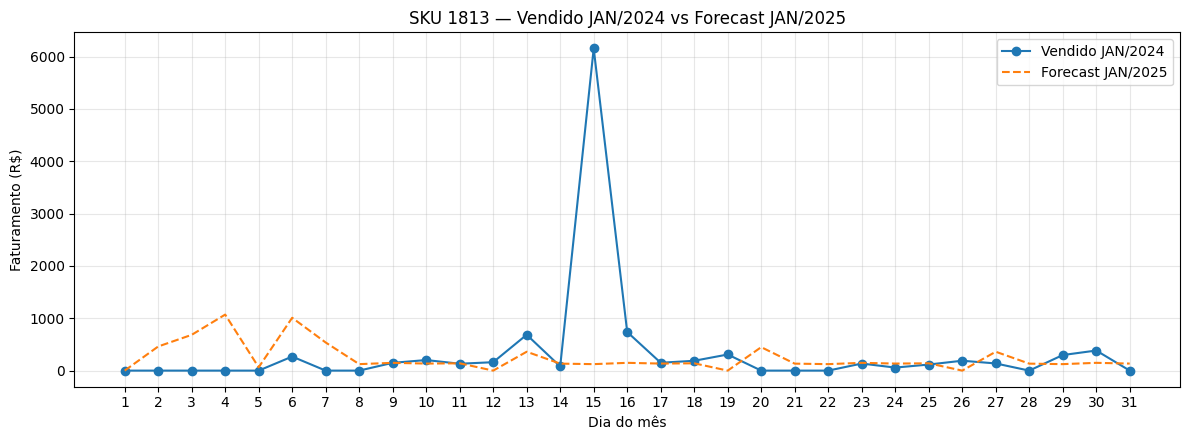

In [184]:
# Bloco 6 — Gráfico comparativo JAN/2024 vs JAN/2025
import matplotlib.pyplot as plt

jan_2024 = df[(df['DATA_ATEND'] >= '2024-01-01') & (df['DATA_ATEND'] <= '2024-01-31') & (df['SKU'].astype(str) == sku_alvo)][['DATA_ATEND', TARGET]].copy()
jan_2024['DIA'] = jan_2024['DATA_ATEND'].dt.day
base_dias = pd.DataFrame({'DIA': range(1, 32)})
real_2024 = base_dias.merge(jan_2024.groupby('DIA', as_index=False)[TARGET].sum(), on='DIA', how='left').fillna({TARGET:0.0})

prev_2025 = df_forecast_1813_jan.copy()
prev_2025['DIA'] = prev_2025['DATA_ATEND'].dt.day
prev_2025 = base_dias.merge(prev_2025.groupby('DIA', as_index=False)['Previsto'].sum(), on='DIA', how='left').fillna({'Previsto':0.0})

plt.figure(figsize=(12,4.5))
plt.plot(real_2024['DIA'], real_2024[TARGET], label='Vendido JAN/2024', marker='o')
plt.plot(prev_2025['DIA'], prev_2025['Previsto'], label='Forecast JAN/2025', linestyle='--')
plt.title("SKU 1813 — Vendido JAN/2024 vs Forecast JAN/2025")
plt.xlabel("Dia do mês"); plt.ylabel("Faturamento (R$)")
plt.xticks(range(1,32)); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()


No dia 15 de Abril um único cliente comprou 100kg do SKU 1813, sendo o driver único da receita naquele dia

### 7. Previsão da demanda

Visão Geral: Sabendo a quantidade que o modelo vai vender em Janeiro de 2024 vamos usar a mediana ponderada do preço (R$/kg) em 2024 para entender como o preço do SKU 1813 comporta-se e logo após vamos calcular a quantidade prevista para venda em Kg usando a fórmula (faturamento previsto)/(preço)

In [185]:
# Conversão de forecast (R$) -> quantidade (kg) para o SKU 1813
# Lê vendas se for passado um caminho (str/Path) ou se 'vendas' não existir.
# Usa mediana ponderada do preço (R$/kg) em 2024 e converte o forecast diário para kg,
# incluindo faixa de sensibilidade ±10% no preço e sugestão semanal de compra.

import numpy as np
import pandas as pd
from pathlib import Path

SKU_ALVO = '1813'

vendas= os.path.join('..', 'data', 'raw')
DATA_FILE = os.path.join(vendas, 'vendas.csv')
vendas = pd.read_csv(DATA_FILE)

# --- Sanidade de inputs ---
if 'df_forecast_1813_jan' not in globals():
    raise NameError("'df_forecast_1813_jan' não está definido no notebook.")

req_cols_fore = {'DATA_ATEND','Previsto'}
req_cols_vendas = {'DATA_ATEND','SKU','QTD_VENDA','FATUR_VENDA'}
if not req_cols_fore.issubset(df_forecast_1813_jan.columns):
    raise ValueError("df_forecast_1813_jan precisa ter as colunas: 'DATA_ATEND' e 'Previsto'.")
if not req_cols_vendas.issubset(vendas.columns):
    raise ValueError("vendas precisa ter as colunas: 'DATA_ATEND','SKU','QTD_VENDA','FATUR_VENDA'.")

# --- Prepara dados 2024 do SKU ---
vendas['DATA_ATEND'] = pd.to_datetime(vendas['DATA_ATEND'], errors='coerce')
mask_2024 = vendas['DATA_ATEND'].dt.year.eq(2024)
mask_sku  = vendas['SKU'].astype(str).eq(SKU_ALVO)

df_1813_2024 = vendas.loc[mask_2024 & mask_sku, ['DATA_ATEND','QTD_VENDA','FATUR_VENDA']].copy()
df_1813_2024 = df_1813_2024[(df_1813_2024['QTD_VENDA']>0) & (df_1813_2024['FATUR_VENDA']>0)]
if df_1813_2024.empty:
    raise ValueError("Não há vendas válidas (QTD/FATUR > 0) do SKU 1813 em 2024 para estimar preço.")

# --- Preço unitário e limpeza de outliers (winsorização 5–95%) ---
df_1813_2024['preco_unit'] = df_1813_2024['FATUR_VENDA'] / df_1813_2024['QTD_VENDA']
p5, p95 = np.percentile(df_1813_2024['preco_unit'], [5, 95])
df_1813_2024 = df_1813_2024[(df_1813_2024['preco_unit']>=p5) & (df_1813_2024['preco_unit']<=p95)]
if df_1813_2024.empty:
    raise ValueError("Após filtro de outliers, não há dados suficientes para estimar preço.")

# --- Mediana ponderada do preço (pesos = QTD) ---
def weighted_median(values, weights):
    order = np.argsort(values)
    v = np.array(values)[order]
    w = np.array(weights)[order]
    cw = np.cumsum(w) / np.sum(w)
    return v[np.searchsorted(cw, 0.5)]

preco_tipico = float(weighted_median(df_1813_2024['preco_unit'].values,
                                     df_1813_2024['QTD_VENDA'].values))
if not np.isfinite(preco_tipico) or preco_tipico <= 0:
    raise ValueError("Preço típico inválido (<=0 ou NaN).")

# --- Converte forecast para kg + faixa de sensibilidade ±10% no preço ---
df_conv = df_forecast_1813_jan.copy()
df_conv['DATA_ATEND'] = pd.to_datetime(df_conv['DATA_ATEND'], errors='coerce')

df_conv['kg_central'] = (df_conv['Previsto'] / preco_tipico).astype('float32')
df_conv['kg_low(+10% preço)']  = (df_conv['Previsto'] / (preco_tipico*1.10)).astype('float32')
df_conv['kg_high(-10% preço)'] = (df_conv['Previsto'] / (preco_tipico*0.90)).astype('float32')

# Totais do mês
tot_fatur = df_conv['Previsto'].sum()
tot_kg    = df_conv['kg_central'].sum()
tot_kg_lo = df_conv['kg_low(+10% preço)'].sum()
tot_kg_hi = df_conv['kg_high(-10% preço)'].sum()

print("=== Conversão Forecast → Quantidade (kg) | SKU 1813 ===")
print(f"Preço típico 2024 (mediana ponderada): R$ {preco_tipico:,.2f}/kg")
print(f"Total JAN/2025 previsto (R$):          R$ {tot_fatur:,.2f}")
print(f"Total JAN/2025 estimado (kg):          {tot_kg:,.2f} kg")
print(f"Faixa (sensibilidade ±10% no preço):   [{tot_kg_lo:,.2f} kg  ~  {tot_kg_hi:,.2f} kg]")


=== Conversão Forecast → Quantidade (kg) | SKU 1813 ===
Preço típico 2024 (mediana ponderada): R$ 69.90/kg
Total JAN/2025 previsto (R$):          R$ 7,440.40
Total JAN/2025 estimado (kg):          106.44 kg
Faixa (sensibilidade ±10% no preço):   [96.76 kg  ~  118.27 kg]
